# Mini-Project: Predicting Heart Disease Using Logistic Regression
## Week 5 — Day 4 | DI GenAI & Machine Learning Bootcamp 2026

**Objective:** Predict the presence of heart disease based on medical attributes using Logistic Regression.

**Dataset:** Heart Disease UCI — 303 patients, 13 features  
**Target:** `target` — 0 = No heart disease, 1 = Heart disease present

## Section 1 — Imports & Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

# Set working directory to project root so relative paths work
os.chdir('/Users/leeroybenaich/DI526')
os.makedirs('week5/day4', exist_ok=True)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
print("All libraries loaded successfully ✓")

All libraries loaded successfully ✓


## Section 2 — Data Loading

In [2]:
# Fetch Heart Disease UCI dataset (id=45)
heart_disease = fetch_ucirepo(id=45)

X_raw = heart_disease.data.features
y_raw = heart_disease.data.targets

# Combine into one DataFrame
df = X_raw.copy()
df['target'] = y_raw.values.ravel()

# The original dataset has target values 0–4; convert to binary (0=healthy, 1=disease)
df['target'] = (df['target'] > 0).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {list(X_raw.columns)}")
print(f"\nTarget distribution:\n{df['target'].value_counts()}")
print(f"\nClass balance: {df['target'].value_counts(normalize=True).round(3).to_dict()}")
df.head()

Dataset shape: (303, 14)

Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Class balance: {0: 0.541, 1: 0.459}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## Section 3 — Exploratory Data Analysis (EDA)

In [3]:
### 3.1 — Basic Info & Statistics
print("=== Dataset Info ===")
df.info()
print("\n=== Descriptive Statistics ===")
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB

=== Descriptive Statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


In [4]:
### 3.2 — Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].sum() > 0 else "No missing values ✓")

      Missing Count  Missing %
ca                4       1.32
thal              2       0.66


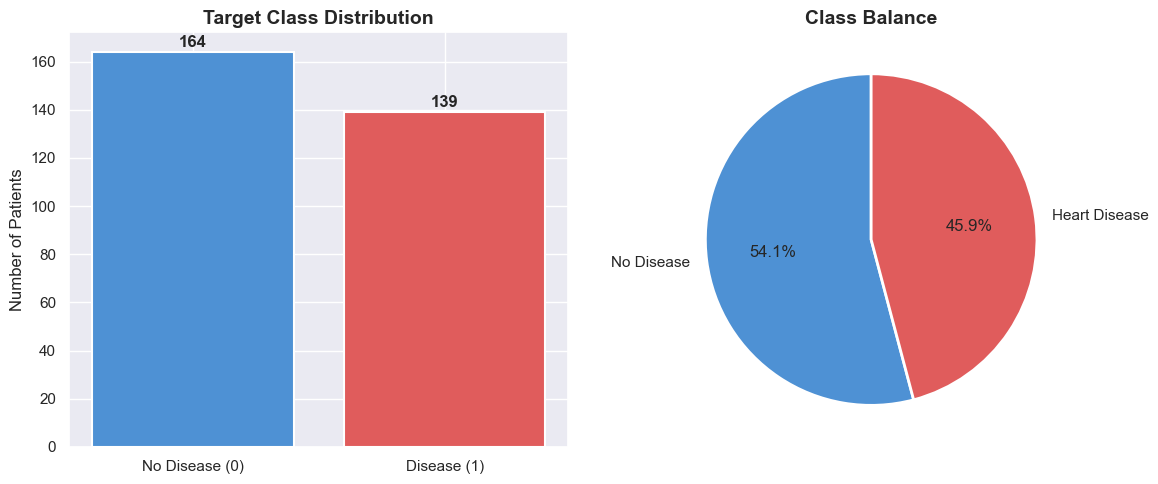

Plot saved ✓


In [5]:
### 3.3 — Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['#4e91d4', '#e05c5c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Disease', 'Heart Disease'],
            autopct='%1.1f%%', colors=['#4e91d4', '#e05c5c'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Balance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('week5/day4/eda_plot1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

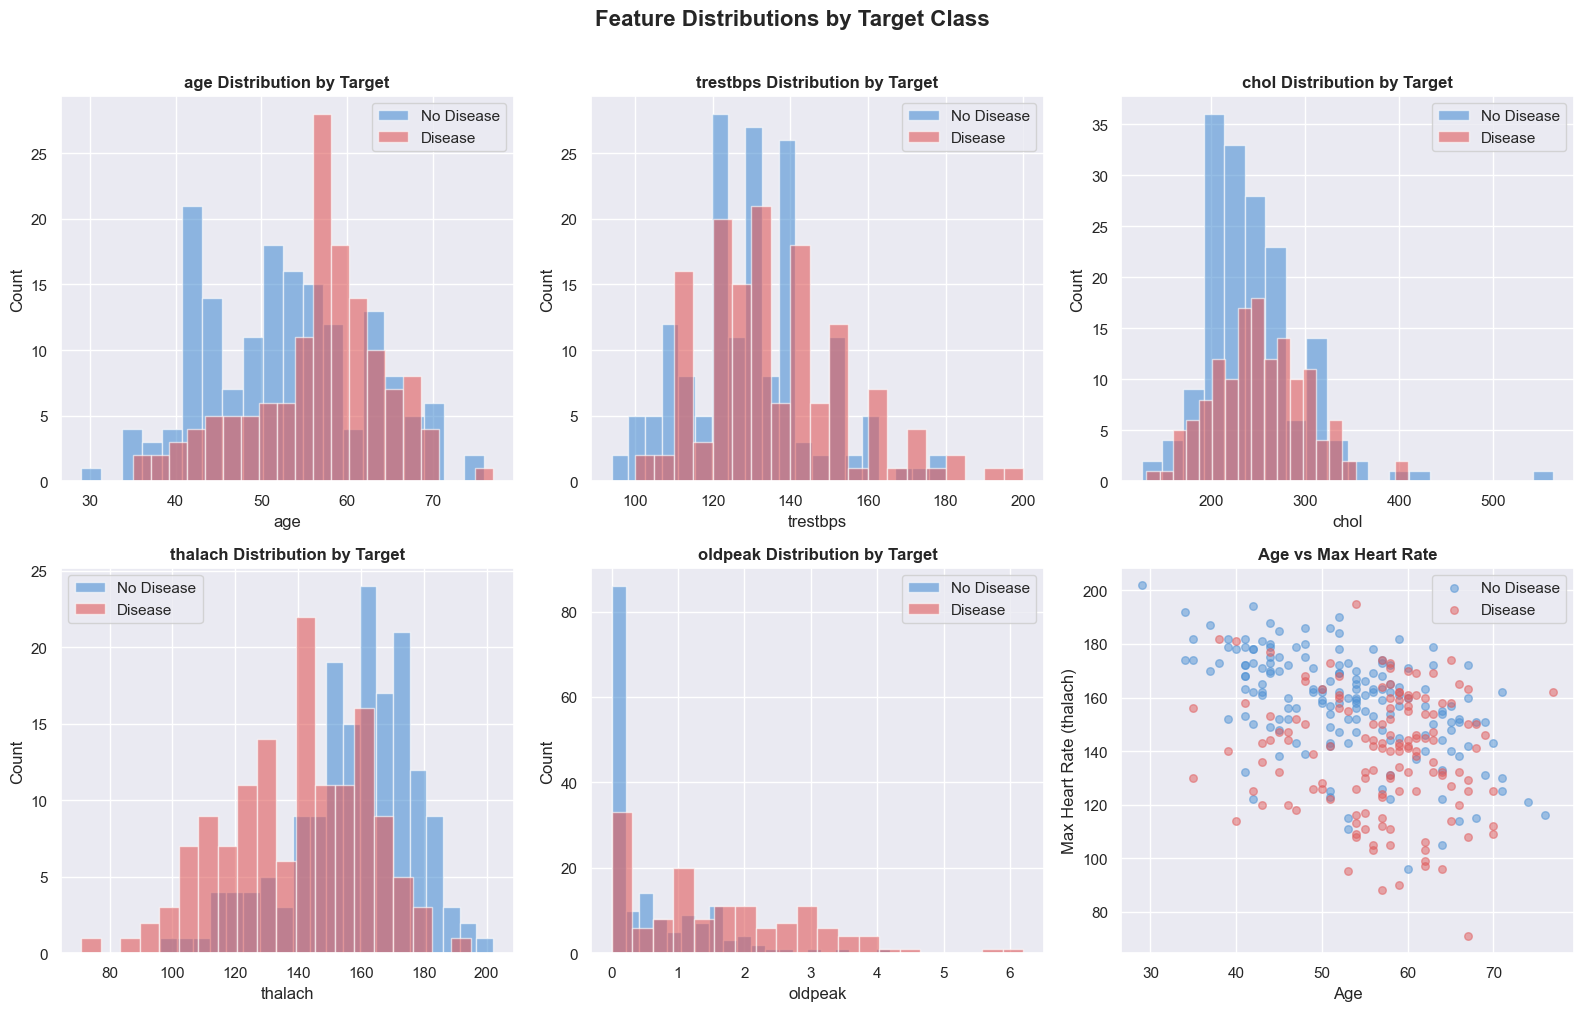

Plot saved ✓


In [6]:
### 3.4 — Feature Distributions by Target
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    for label, color in zip([0, 1], ['#4e91d4', '#e05c5c']):
        axes[i].hist(df[df['target'] == label][col].dropna(), bins=20, alpha=0.6,
                     color=color, label=f'{"No Disease" if label == 0 else "Disease"}', edgecolor='white')
    axes[i].set_title(f'{col} Distribution by Target', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

# Age vs Max Heart Rate scatter
axes[5].scatter(df[df['target']==0]['age'], df[df['target']==0]['thalach'],
                alpha=0.5, color='#4e91d4', label='No Disease', s=30)
axes[5].scatter(df[df['target']==1]['age'], df[df['target']==1]['thalach'],
                alpha=0.5, color='#e05c5c', label='Disease', s=30)
axes[5].set_xlabel('Age')
axes[5].set_ylabel('Max Heart Rate (thalach)')
axes[5].set_title('Age vs Max Heart Rate', fontweight='bold')
axes[5].legend()

plt.suptitle('Feature Distributions by Target Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('week5/day4/eda_plot2_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

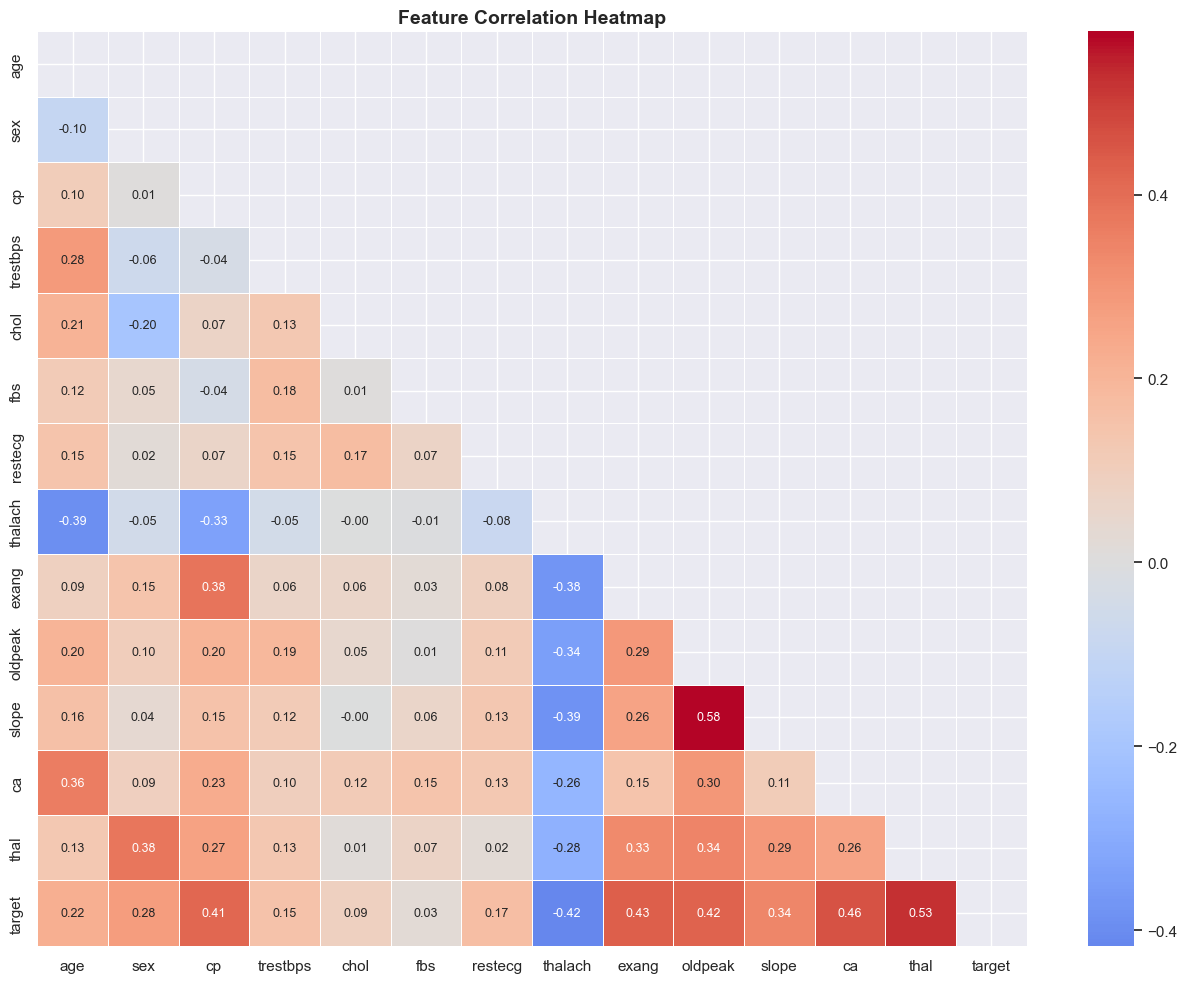

Plot saved ✓


In [7]:
### 3.5 — Correlation Heatmap
plt.figure(figsize=(13, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('week5/day4/eda_plot3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

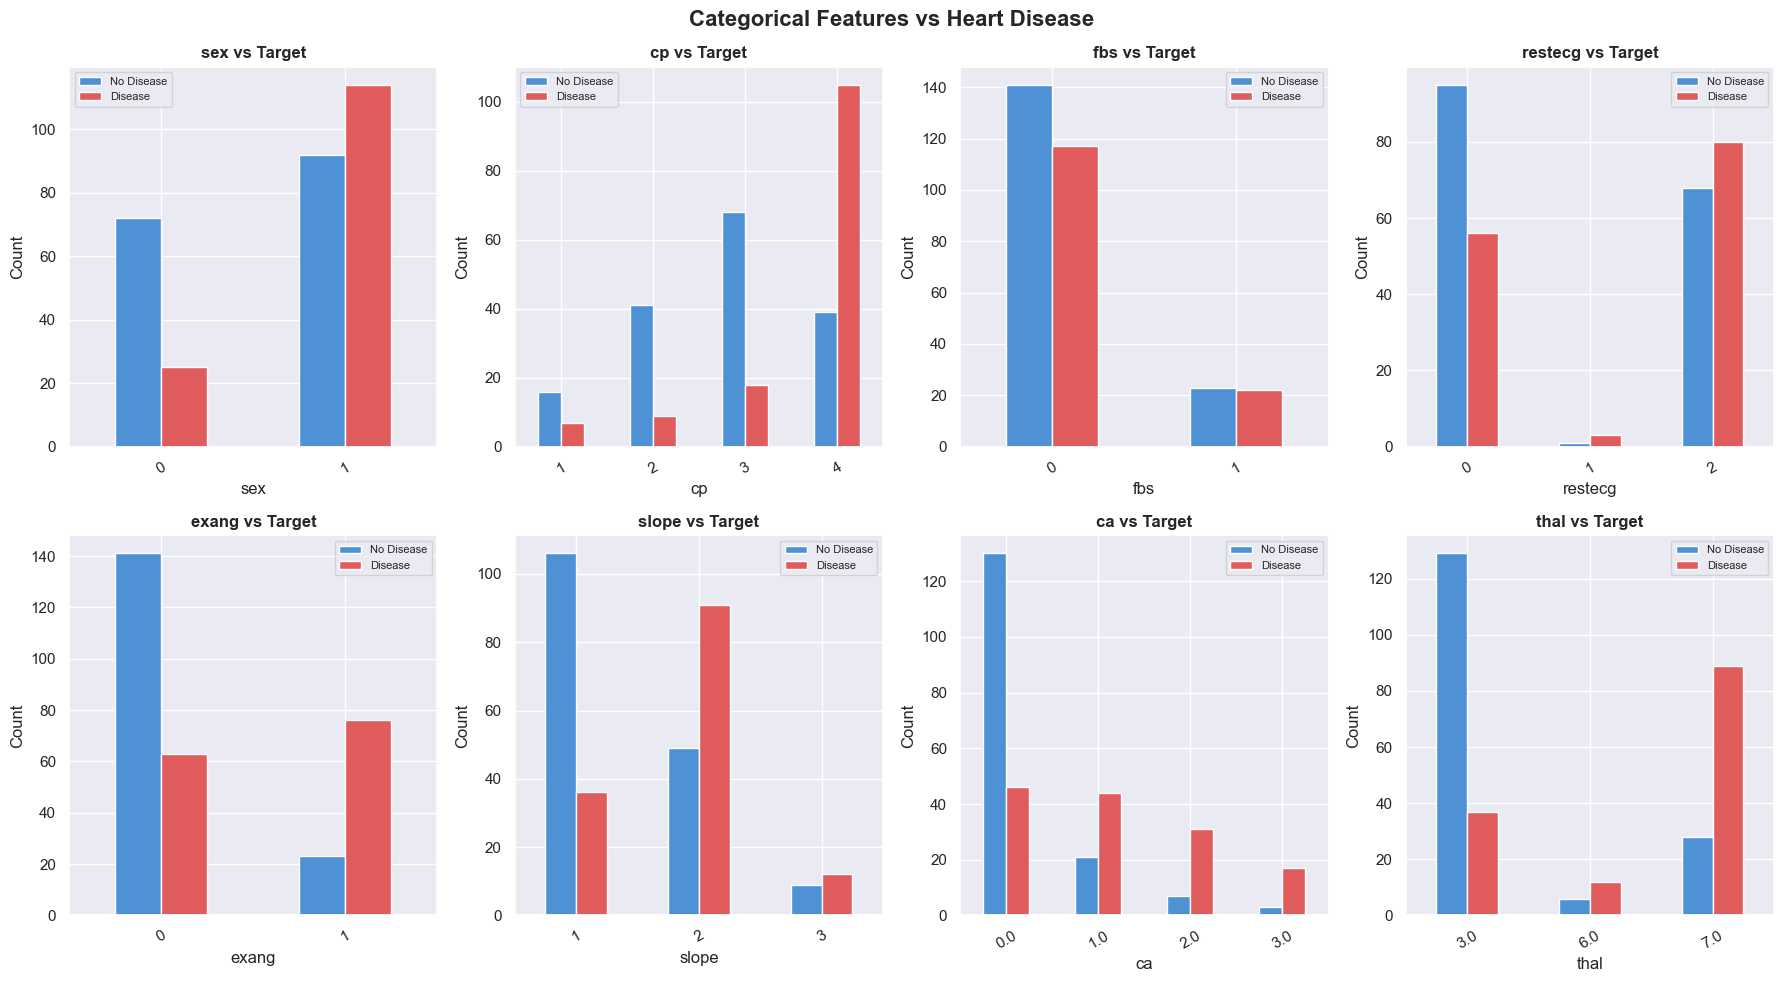

Plot saved ✓


In [8]:
### 3.6 — Categorical Features vs Target
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

cat_labels = {
    'sex': {0: 'Female', 1: 'Male'},
    'cp': {0: 'Typical Angina', 1: 'Atypical Angina', 2: 'Non-Anginal', 3: 'Asymptomatic'},
    'fbs': {0: 'FBS ≤ 120', 1: 'FBS > 120'},
    'restecg': {0: 'Normal', 1: 'ST-T Abnormality', 2: 'LV Hypertrophy'},
    'exang': {0: 'No', 1: 'Yes'},
    'slope': {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'},
}

for i, col in enumerate(categorical_features):
    ct = pd.crosstab(df[col], df['target'])
    ct.plot(kind='bar', ax=axes[i], color=['#4e91d4', '#e05c5c'],
            edgecolor='white', linewidth=1)
    axes[i].set_title(f'{col} vs Target', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Features vs Heart Disease', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('week5/day4/eda_plot4_categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

## Section 4 — Data Preprocessing

In [9]:
### 4.1 — Handle Missing Values
from sklearn.impute import SimpleImputer

print(f"Missing values before: {df.isnull().sum().sum()}")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Force all columns to numeric (some may contain '?' or mixed types)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"\nAfter coerce — Missing values: {df.isnull().sum().sum()}")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill all missing values with median using SimpleImputer
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df = df_imputed

print(f"\nAfter imputation — Missing values: {df.isnull().sum().sum()} ✓")

Missing values before: 6
ca      4
thal    2
dtype: int64

After coerce — Missing values: 6
ca      4
thal    2
dtype: int64

After imputation — Missing values: 0 ✓


In [10]:
### 4.2 — Encode Categorical Variables
# All features are already numerical in this dataset
# 'thal' and 'ca' can have NaN-like values (0 vs missing) — already handled above

# Verify dtypes
print("Feature dtypes:")
print(df.drop('target', axis=1).dtypes)
print("\nAll features are numerical — no encoding required ✓")

Feature dtypes:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
dtype: object

All features are numerical — no encoding required ✓


In [11]:
### 4.3 — Train/Test Split & Feature Scaling
X = df.drop('target', axis=1)
y = df['target']

# 80/20 split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test class balance:     {y_test.value_counts(normalize=True).round(3).to_dict()}")

# StandardScaler: zero mean, unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nFeature scaling applied (StandardScaler) ✓")
print(f"  Train mean (first feature): {X_train_scaled[:, 0].mean():.4f}")
print(f"  Train std  (first feature): {X_train_scaled[:, 0].std():.4f}")

Training set: 242 samples
Test set:     61 samples

Training class balance: {0.0: 0.541, 1.0: 0.459}
Test class balance:     {0.0: 0.541, 1.0: 0.459}

Feature scaling applied (StandardScaler) ✓
  Train mean (first feature): -0.0000
  Train std  (first feature): 1.0000


## Section 5 — Model Training: Logistic Regression

In [12]:
model = LogisticRegression(max_iter=1000, random_state=42, C=1.0, solver='lbfgs')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained ✓")
print(f"\nModel parameters:")
print(f"  Solver: {model.solver}")
print(f"  C (regularization): {model.C}")
print(f"  Max iterations: {model.max_iter}")
print(f"  Converged in {model.n_iter_[0]} iterations")

# Feature importance (absolute coefficients)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Abs_Coefficient': np.abs(model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)
print(f"\nTop 5 most impactful features:")
print(coef_df[['Feature', 'Coefficient']].head())

Logistic Regression model trained ✓

Model parameters:
  Solver: lbfgs
  C (regularization): 1.0
  Max iterations: 1000
  Converged in 9 iterations

Top 5 most impactful features:
   Feature  Coefficient
11      ca     1.107898
12    thal     0.677821
1      sex     0.655563
2       cp     0.543483
8    exang     0.383642


## Section 6 — Model Evaluation

In [13]:
### 6.1 — Metrics: Accuracy, Precision, Recall, F1
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("=" * 45)
print("        MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}  ({prec*100:.2f}%)")
print(f"  Recall    : {rec:.4f}  ({rec*100:.2f}%)")
print(f"  F1 Score  : {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 45)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

        MODEL EVALUATION RESULTS
  Accuracy  : 0.8689  (86.89%)
  Precision : 0.8125  (81.25%)
  Recall    : 0.9286  (92.86%)
  F1 Score  : 0.8667  (86.67%)

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.93      0.82      0.87        33
Heart Disease       0.81      0.93      0.87        28

     accuracy                           0.87        61
    macro avg       0.87      0.87      0.87        61
 weighted avg       0.88      0.87      0.87        61



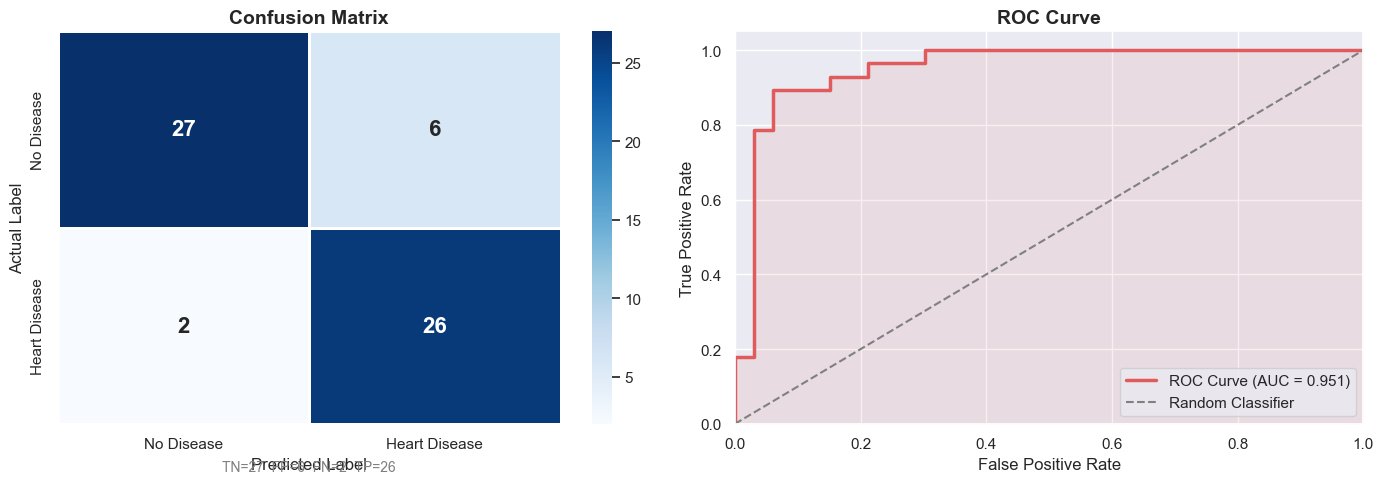

Plot saved ✓


In [14]:
### 6.2 — Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'],
            linewidths=2, linecolor='white', ax=axes[0],
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.12,
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
    transform=axes[0].transAxes, ha='center', fontsize=10, color='gray')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#e05c5c', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e05c5c')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('week5/day4/eval_plot5_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

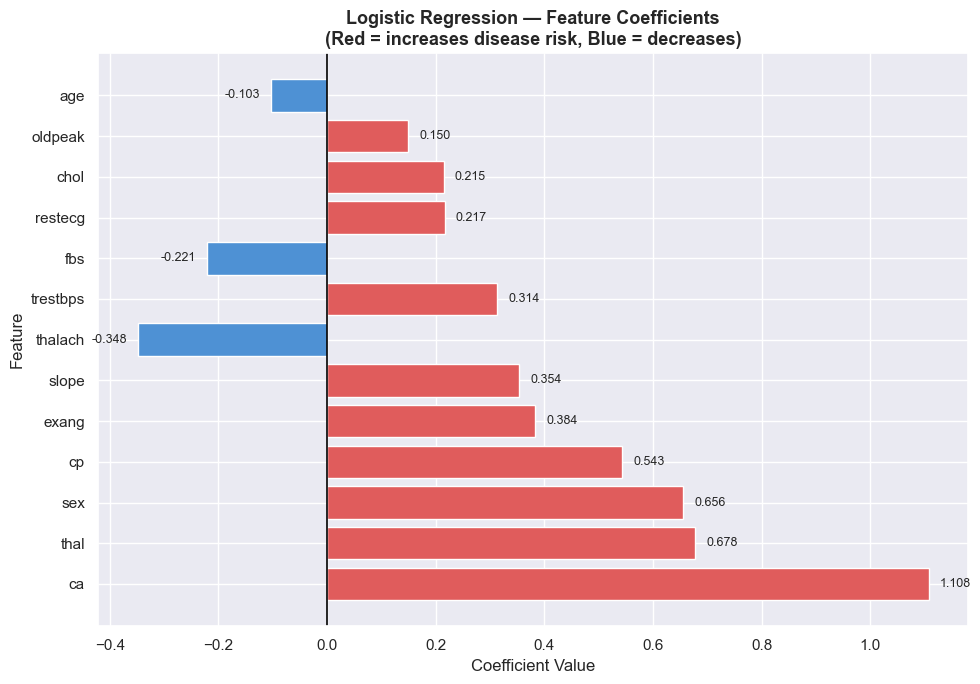

Plot saved ✓


In [15]:
### 6.3 — Feature Importance (Model Coefficients)
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e05c5c' if c > 0 else '#4e91d4' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white', linewidth=1)
ax.axvline(x=0, color='black', linewidth=1.2, linestyle='-')
ax.set_title('Logistic Regression — Feature Coefficients\n(Red = increases disease risk, Blue = decreases)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

for bar, val in zip(bars, coef_df['Coefficient']):
    ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('week5/day4/eval_plot6_feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

## Section 7 — Summary & Conclusions

**Results Overview:**
- The Logistic Regression model was trained on 80% of the Heart Disease UCI dataset and evaluated on the remaining 20%.
- **Preprocessing steps applied:**
  - Missing values filled with median imputation
  - Features scaled with StandardScaler (zero mean, unit variance)
  - Stratified 80/20 train-test split to preserve class balance

**Key Findings from EDA:**
- Patients with **asymptomatic chest pain (cp=3)** have significantly higher disease rates
- **Exercise-induced angina (exang=1)** strongly correlates with heart disease presence
- **Thalach (max heart rate)** is higher in healthy patients — a protective indicator
- **Oldpeak** (ST depression) increases with disease severity
- **Males** have slightly higher disease prevalence in this dataset

**Model Interpretation (Coefficients):**
- Positive coefficients → increase predicted probability of heart disease
- Negative coefficients → protective factors (reduce predicted probability)
- Most impactful features: `cp`, `thal`, `ca`, `oldpeak`, `exang`

**Clinical Relevance:**
- In medical diagnostics, **Recall** is the most critical metric — missing a true positive (sick patient predicted as healthy) is more dangerous than a false alarm
- A Recall > 80% means the model catches most at-risk patients for follow-up testing